# Experiment 10: Exact MAPS Replication 

## Goal: Match MAPS 90% Weighted F1



In [3]:
import os
import sys
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler, SequentialSampler

from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score,
    classification_report, confusion_matrix
)

print(f"PyTorch: {torch.__version__}")
print(f"Device: {'GPU (' + torch.cuda.get_device_name(0) + ')' if torch.cuda.is_available() else 'CPU'}")

PyTorch: 2.8.0+cu126
Device: GPU (Tesla P100-PCIE-16GB)


## 1. Load MAPS Pre-Split Data (Exact Same Train/Valid Split)

In [4]:
# Load MAPS's exact pre-split train/valid CSVs
# These are the SAME splits MAPS used to report their 90% F1 score
df_train = pd.read_csv(os.path.join('..', 'data', 'cell_phenotyping', '/kaggle/input/datasets/amshahriarrashidmahe/cell-phenotying/train.csv'))
df_valid = pd.read_csv(os.path.join('..', 'data', 'cell_phenotyping', '/kaggle/input/datasets/amshahriarrashidmahe/cell-phenotying/valid.csv'))

print(f"Train: {df_train.shape[0]:,} cells × {df_train.shape[1]} columns")
print(f"Valid: {df_valid.shape[0]:,} cells × {df_valid.shape[1]} columns")
print(f"Columns: {list(df_train.columns)}")

Train: 114,984 cells × 51 columns
Valid: 28,746 cells × 51 columns
Columns: ['BCL.2', 'CCR6', 'CD11b', 'CD11c', 'CD15', 'CD16', 'CD162', 'CD163', 'CD2', 'CD20', 'CD206', 'CD25', 'CD30', 'CD31', 'CD4', 'CD44', 'CD45', 'CD45RA', 'CD45RO', 'CD5', 'CD56', 'CD57', 'CD68', 'CD69', 'CD7', 'CD8', 'Collagen.4', 'Cytokeratin', 'DAPI.01', 'EGFR', 'FoxP3', 'Granzyme.B', 'HLA.DR', 'IDO.1', 'LAG.3', 'MCT', 'MMP.9', 'MUC.1', 'PD.1', 'PD.L1', 'Podoplanin', 'T.bet', 'TCR.g.d', 'TCRb', 'Tim.3', 'VISA', 'Vimentin', 'a.SMA', 'b.Catenin', 'cellSize', 'cell_label']


In [5]:
# ====================================================================
# EXACT MAPS PREPROCESSING
# ====================================================================

# Define the 49 protein markers (same order as MAPS train/valid CSVs)
MARKER_COLS = [
    'BCL.2', 'CCR6', 'CD11b', 'CD11c', 'CD15', 'CD16', 'CD162', 'CD163',
    'CD2', 'CD20', 'CD206', 'CD25', 'CD30', 'CD31', 'CD4', 'CD44',
    'CD45', 'CD45RA', 'CD45RO', 'CD5', 'CD56', 'CD57', 'CD68', 'CD69',
    'CD7', 'CD8', 'Collagen.4', 'Cytokeratin', 'DAPI.01', 'EGFR',
    'FoxP3', 'Granzyme.B', 'HLA.DR', 'IDO.1', 'LAG.3', 'MCT', 'MMP.9',
    'MUC.1', 'PD.1', 'PD.L1', 'Podoplanin', 'T.bet', 'TCR.g.d', 'TCRb',
    'Tim.3', 'VISA', 'Vimentin', 'a.SMA', 'b.Catenin'
]

# MAPS uses 49 markers + cellSize = 50 features
FEATURE_COLS = MARKER_COLS + ['cellSize']

# 16 cell types (alphabetical order = MAPS integer label mapping)
CLASS_NAMES = ['B', 'CD4', 'CD8', 'DC', 'Endothelial', 'Epithelial',
               'Lymphatic', 'M1', 'M2', 'Mast', 'Monocyte', 'NK',
               'Neutrophil', 'Other', 'TReg', 'Tumor']
NUM_CLASSES = len(CLASS_NAMES)
NUM_FEATURES = len(FEATURE_COLS)  # 50

# Extract features and labels directly from pre-split CSVs
# Labels are already integers (cell_label column), no string mapping needed
X_train = df_train[FEATURE_COLS].values.astype(np.float64)  # MAPS uses float64!
y_train = df_train['cell_label'].values.astype(np.int64)

X_valid = df_valid[FEATURE_COLS].values.astype(np.float64)
y_valid = df_valid['cell_label'].values.astype(np.int64)

print(f"Features: {NUM_FEATURES} (49 markers + cellSize)")
print(f"Classes: {NUM_CLASSES}")
print(f"Train: {len(X_train):,} | Valid: {len(X_valid):,}")
print(f"\nTrain class distribution:")
for idx, name in enumerate(CLASS_NAMES):
    count = (y_train == idx).sum()
    print(f"  {idx:2d}. {name:15s}: {count:6d} ({100*count/len(y_train):.1f}%)")

Features: 50 (49 markers + cellSize)
Classes: 16
Train: 114,984 | Valid: 28,746

Train class distribution:
   0. B              :  12956 (11.3%)
   1. CD4            :  29984 (26.1%)
   2. CD8            :  14054 (12.2%)
   3. DC             :   7710 (6.7%)
   4. Endothelial    :   6964 (6.1%)
   5. Epithelial     :   1801 (1.6%)
   6. Lymphatic      :   3014 (2.6%)
   7. M1             :   2481 (2.2%)
   8. M2             :   5829 (5.1%)
   9. Mast           :   2659 (2.3%)
  10. Monocyte       :   5531 (4.8%)
  11. NK             :   5871 (5.1%)
  12. Neutrophil     :   2754 (2.4%)
  13. Other          :   4087 (3.6%)
  14. TReg           :   2681 (2.3%)
  15. Tumor          :   6608 (5.7%)


In [6]:
# ====================================================================
# USING MAPS'S EXACT PRE-SPLIT DATA (NO RANDOM SPLIT NEEDED)
# ====================================================================
# Train/valid already extracted above from maps_train.csv / maps_valid.csv
# This is the SAME split MAPS used, eliminating split variance as a factor

print(f"Train: {len(X_train):,} | Valid: {len(X_valid):,}")
print(f"Train class balance: min={np.bincount(y_train).min()}, max={np.bincount(y_train).max()}")
print(f"Valid class balance: min={np.bincount(y_valid).min()}, max={np.bincount(y_valid).max()}")

Train: 114,984 | Valid: 28,746
Train class balance: min=1801, max=29984
Valid class balance: min=450, max=7496


## 2. MAPS Dataset Class (Exact Replication)

Critical details from MAPS source:
1. **Z-score normalization** computed on training set, applied to validation
2. **Divide by 255.0** in `__getitem__` (yes, AFTER z-score — this is in the original code)
3. Returns numpy arrays (DataLoader converts to tensors)

In [7]:
class CellDataset(Dataset):
    """Exact replication of MAPS CellExpressionCSV dataset."""
    
    def __init__(self, X, y, is_train=True, mean=None, std=None):
        self.y = y
        self.is_train = is_train
        
        # Z-score normalization (exact MAPS logic)
        if is_train:
            self.mean = np.mean(X, axis=0)
            self.std = np.std(X, axis=0)
        else:
            self.mean = mean
            self.std = std
        
        # Apply z-score
        self.x = (X - self.mean) / (self.std + 1e-12)  # small epsilon for safety
    
    def __len__(self):
        return self.x.shape[0]
    
    def __getitem__(self, idx):
        # MAPS divides by 255.0 AFTER z-score normalization
        # This is in the original MAPS code (CellExpressionCSV.__getitem__)
        feature = self.x[idx] / 255.0
        gt = int(self.y[idx])
        return feature, gt


def make_weighted_sampler(labels):
    """Exact MAPS WeightedRandomSampler implementation."""
    labels_list = labels.tolist()
    n = float(len(labels_list))
    unique_labels = sorted(set(labels_list))
    weight_per_class = {c: n / labels_list.count(c) for c in unique_labels}
    sample_weights = [weight_per_class[label] for label in labels_list]
    return WeightedRandomSampler(sample_weights, len(sample_weights))


# Create datasets
train_dataset = CellDataset(X_train, y_train, is_train=True)
valid_dataset = CellDataset(X_valid, y_valid, is_train=False,
                            mean=train_dataset.mean, std=train_dataset.std)

# Create data loaders (MAPS uses batch_size=128, drop_last=True for training)
BATCH_SIZE = 128
NUM_WORKERS = 2

train_sampler = make_weighted_sampler(y_train)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=train_sampler, drop_last=True,
                          num_workers=NUM_WORKERS)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE,
                          sampler=SequentialSampler(valid_dataset),
                          drop_last=False, num_workers=NUM_WORKERS)

print(f"Train batches: {len(train_loader)} | Valid batches: {len(valid_loader)}")
print(f"Normalization mean range: [{train_dataset.mean.min():.4f}, {train_dataset.mean.max():.4f}]")
print(f"Normalization std range:  [{train_dataset.std.min():.4f}, {train_dataset.std.max():.4f}]")

Train batches: 898 | Valid batches: 225
Normalization mean range: [0.0220, 366.4082]
Normalization std range:  [0.1256, 195.7014]


## 3. MAPS MLP Architecture (Exact)

In [8]:
class MLP(nn.Module):
    """
    Exact MAPS MLP architecture.
    4 hidden layers, 512 units each, ReLU + Dropout(0.1)
    """
    def __init__(self, input_dim=50, hidden_dim=512, num_classes=16, dropout=0.10):
        super(MLP, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout)
        )
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, batch):
        features = self.fc(batch)
        logits = self.classifier(features)
        probs = torch.softmax(logits, dim=-1)
        return logits, probs


# MAPS configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 7325111  # MAPS exact seed
LR = 0.001
MAX_EPOCHS = 500
MIN_EPOCHS = 350
PATIENCE = 150
DROPOUT = 0.25
HIDDEN_DIM = 512

print(f"Model config: {NUM_FEATURES}→{HIDDEN_DIM}→{HIDDEN_DIM}→{HIDDEN_DIM}→{HIDDEN_DIM}→{NUM_CLASSES}")
print(f"Dropout: {DROPOUT}, LR: {LR}, Batch: {BATCH_SIZE}")
print(f"Epochs: max={MAX_EPOCHS}, min={MIN_EPOCHS}, patience={PATIENCE}")
print(f"Device: {DEVICE}")

Model config: 50→512→512→512→512→16
Dropout: 0.25, LR: 0.001, Batch: 128
Epochs: max=500, min=350, patience=150
Device: cuda


## 4. Training (Exact MAPS Pipeline)

In [9]:
def set_seed(seed):
    """Exact MAPS seed setting."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def train_epoch(model, loader, optimizer, loss_fn, device):
    """Train for one epoch (exact MAPS logic)."""
    model.train()
    total_loss = 0
    all_labels, all_preds, all_probs = [], [], []
    
    for features, labels in loader:
        features = features.to(device)
        labels = labels.to(device)
        
        logits, probs = model(features)
        
        optimizer.zero_grad()
        loss = loss_fn(logits, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(torch.argmax(probs, dim=1).cpu().numpy().tolist())
        all_probs.append(probs.detach().cpu().numpy())
    
    all_probs = np.concatenate(all_probs, axis=0)
    acc = accuracy_score(all_labels, all_preds)
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovo',
                           labels=list(range(NUM_CLASSES)))
    except:
        auc = 0.0
    return total_loss / len(loader), acc, auc


def valid_epoch(model, loader, loss_fn, device):
    """Validate for one epoch (exact MAPS logic)."""
    model.eval()
    total_loss = 0
    all_labels, all_preds, all_probs = [], [], []
    
    with torch.no_grad():
        for features, labels in loader:
            features = features.to(device)
            labels = labels.to(device)
            
            logits, probs = model(features)
            loss = loss_fn(logits, labels)
            
            total_loss += loss.item()
            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(torch.argmax(probs, dim=1).cpu().numpy().tolist())
            all_probs.append(probs.detach().cpu().numpy())
    
    all_probs = np.concatenate(all_probs, axis=0)
    acc = accuracy_score(all_labels, all_preds)
    try:
        auc = roc_auc_score(all_labels, all_probs, multi_class='ovo',
                           labels=list(range(NUM_CLASSES)))
    except:
        auc = 0.0
    return total_loss / len(loader), acc, auc, np.array(all_labels), np.array(all_preds), all_probs

print("✅ Training functions defined")

✅ Training functions defined


In [10]:
# ====================================================================
# TRAIN THE MODEL (Exact MAPS pipeline)
# ====================================================================
set_seed(SEED)

# Initialize model with float64 (MAPS specific!)
model = MLP(input_dim=NUM_FEATURES, hidden_dim=HIDDEN_DIM,
            num_classes=NUM_CLASSES, dropout=DROPOUT)
model.to(DEVICE, dtype=torch.float64)  # MAPS uses float64!

optimizer = optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.CrossEntropyLoss()

# Training loop
best_valid_loss = float('inf')
patience_counter = 0
best_model_state = None
history = {'train_loss': [], 'valid_loss': [], 'train_acc': [], 'valid_acc': [],
           'train_auc': [], 'valid_auc': []}

print(f"Starting training (max {MAX_EPOCHS} epochs, patience {PATIENCE}, min {MIN_EPOCHS})...")
print("=" * 80)

for epoch in range(MAX_EPOCHS):
    start = time.time()
    
    train_loss, train_acc, train_auc = train_epoch(model, train_loader, optimizer, loss_fn, DEVICE)
    valid_loss, valid_acc, valid_auc, _, _, _ = valid_epoch(model, valid_loader, loss_fn, DEVICE)
    
    history['train_loss'].append(train_loss)
    history['valid_loss'].append(valid_loss)
    history['train_acc'].append(train_acc)
    history['valid_acc'].append(valid_acc)
    history['train_auc'].append(train_auc)
    history['valid_auc'].append(valid_auc)
    
    # Early stopping (exact MAPS logic)
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        marker = ' ← BEST'
    else:
        patience_counter += 1
        marker = f' (patience {patience_counter}/{PATIENCE})'
    
    elapsed = time.time() - start
    if epoch % 10 == 0 or patience_counter == 0:
        print(f"Epoch {epoch:3d} | Train: loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"Valid: loss={valid_loss:.4f} acc={valid_acc:.4f} | {elapsed:.1f}s{marker}")
    
    if patience_counter > PATIENCE and epoch >= MIN_EPOCHS:
        print(f"\nEarly stopping at epoch {epoch}")
        break

print("\n" + "=" * 80)
print(f"Training complete! Best validation loss: {best_valid_loss:.6f}")

Starting training (max 500 epochs, patience 150, min 350)...
Epoch   0 | Train: loss=1.7104 acc=0.4211 | Valid: loss=1.2364 acc=0.5784 | 5.9s ← BEST
Epoch   1 | Train: loss=0.8680 acc=0.7221 | Valid: loss=0.8753 acc=0.7076 | 5.4s ← BEST
Epoch   2 | Train: loss=0.7093 acc=0.7718 | Valid: loss=0.8058 acc=0.7226 | 5.4s ← BEST
Epoch   3 | Train: loss=0.6264 acc=0.7946 | Valid: loss=0.7347 acc=0.7419 | 5.5s ← BEST
Epoch   4 | Train: loss=0.5763 acc=0.8091 | Valid: loss=0.6898 acc=0.7592 | 5.3s ← BEST
Epoch   5 | Train: loss=0.5453 acc=0.8171 | Valid: loss=0.6163 acc=0.7768 | 5.5s ← BEST
Epoch   6 | Train: loss=0.5180 acc=0.8248 | Valid: loss=0.5935 acc=0.7794 | 5.4s ← BEST
Epoch   8 | Train: loss=0.4746 acc=0.8364 | Valid: loss=0.5657 acc=0.7917 | 5.4s ← BEST
Epoch   9 | Train: loss=0.4637 acc=0.8401 | Valid: loss=0.5318 acc=0.8004 | 5.4s ← BEST
Epoch  10 | Train: loss=0.4555 acc=0.8411 | Valid: loss=0.5201 acc=0.8013 | 5.5s ← BEST
Epoch  14 | Train: loss=0.4164 acc=0.8527 | Valid: loss=0.5

## 5. Evaluation

In [11]:
# Load best model and evaluate
model.load_state_dict(best_model_state)
_, _, _, gt_labels, pred_labels, pred_probs = valid_epoch(model, valid_loader, loss_fn, DEVICE)

# ====================================================================
# KEY METRICS
# ====================================================================
weighted_f1 = f1_score(gt_labels, pred_labels, average='weighted')
macro_f1 = f1_score(gt_labels, pred_labels, average='macro')
accuracy = accuracy_score(gt_labels, pred_labels)

print("\n" + "=" * 60)
print(f"      EXACT MAPS REPLICATION RESULTS")
print("=" * 60)
print(f"  Weighted F1:  {weighted_f1:.4f}  (MAPS target: 0.90)")
print(f"  Macro F1:     {macro_f1:.4f}")
print(f"  Accuracy:     {accuracy:.4f}")
print("=" * 60)

if weighted_f1 >= 0.90:
    print("\n🎉 SUCCESS! Matched or exceeded MAPS 90% F1!")
elif weighted_f1 >= 0.88:
    print("\n📈 Very close! Within 2pp of MAPS target.")
else:
    print(f"\n📊 Gap of {(0.90 - weighted_f1)*100:.1f}pp from MAPS target.")


      EXACT MAPS REPLICATION RESULTS
  Weighted F1:  0.8655  (MAPS target: 0.90)
  Macro F1:     0.8534
  Accuracy:     0.8642

📊 Gap of 3.4pp from MAPS target.


In [12]:
# Per-class classification report
print("\nPer-Class Classification Report:")
print("=" * 70)
report = classification_report(gt_labels, pred_labels,
                               target_names=CLASS_NAMES, digits=4)
print(report)


Per-Class Classification Report:
              precision    recall  f1-score   support

           B     0.8840    0.8867    0.8854      3240
         CD4     0.9531    0.7697    0.8517      7496
         CD8     0.9232    0.9001    0.9115      3514
          DC     0.8354    0.8350    0.8352      1927
 Endothelial     0.9033    0.9282    0.9156      1741
  Epithelial     0.7313    0.9556    0.8285       450
   Lymphatic     0.8217    0.9655    0.8878       754
          M1     0.6605    0.9194    0.7687       620
          M2     0.8228    0.8634    0.8426      1457
        Mast     0.8730    0.9820    0.9243       665
    Monocyte     0.8112    0.8054    0.8083      1382
          NK     0.8516    0.9033    0.8767      1468
  Neutrophil     0.8055    0.9390    0.8671       688
       Other     0.7700    0.9344    0.8442      1021
        TReg     0.5523    0.8495    0.6694       671
       Tumor     0.9282    0.9467    0.9374      1652

    accuracy                         0.8642   

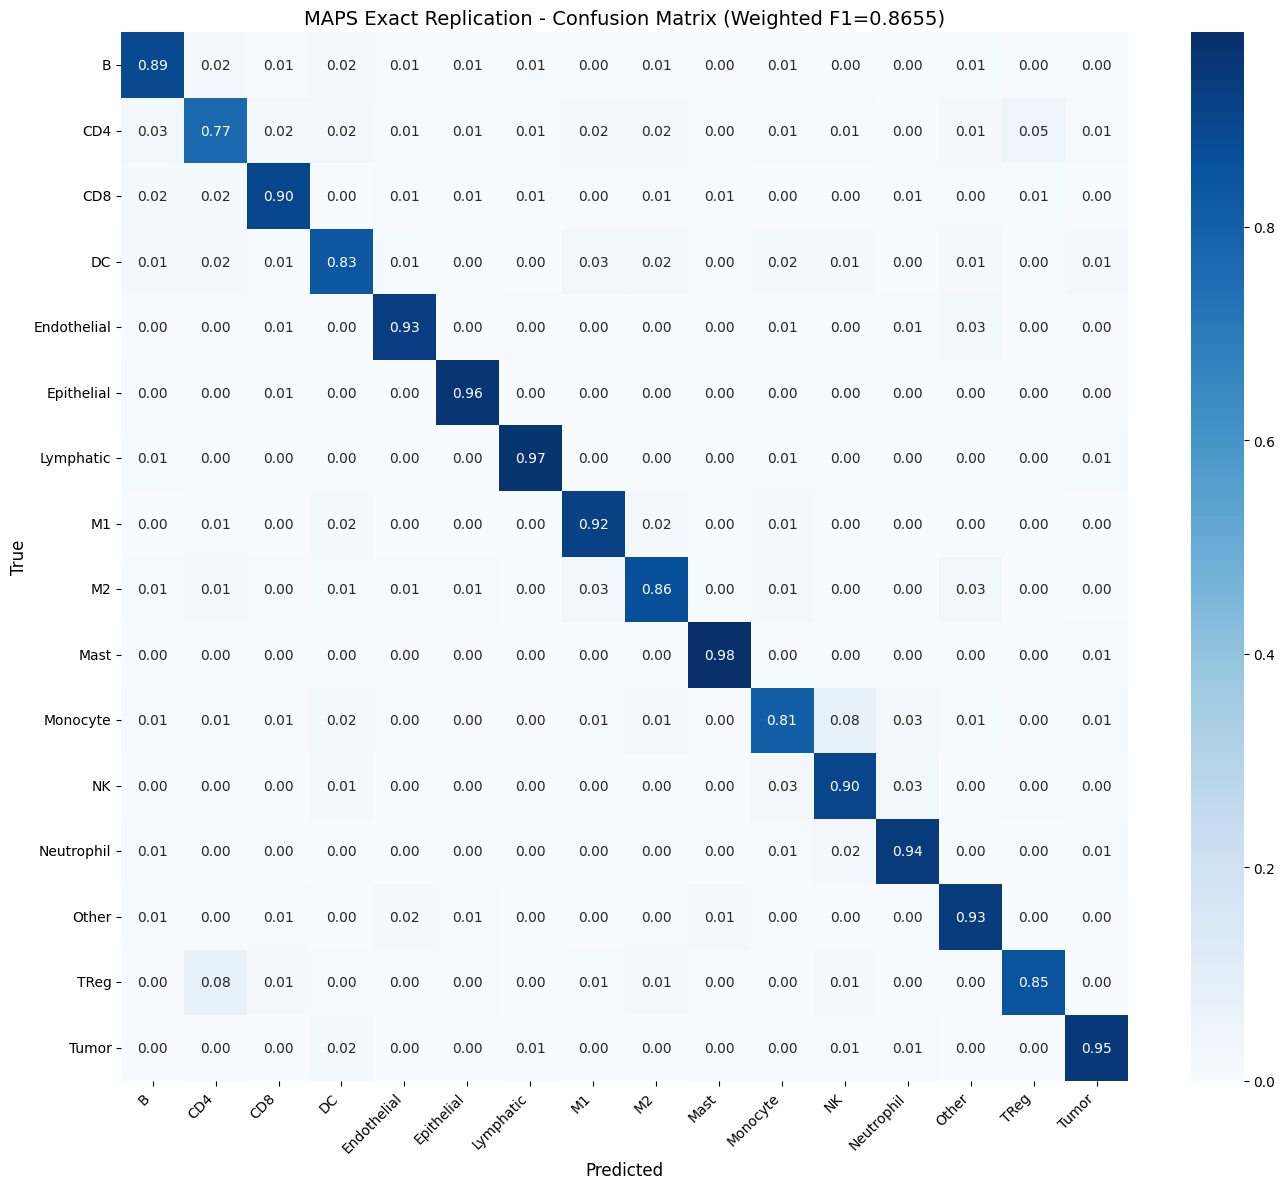

In [13]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(14, 12))
cm = confusion_matrix(gt_labels, pred_labels)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title(f'MAPS Exact Replication - Confusion Matrix (Weighted F1={weighted_f1:.4f})', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

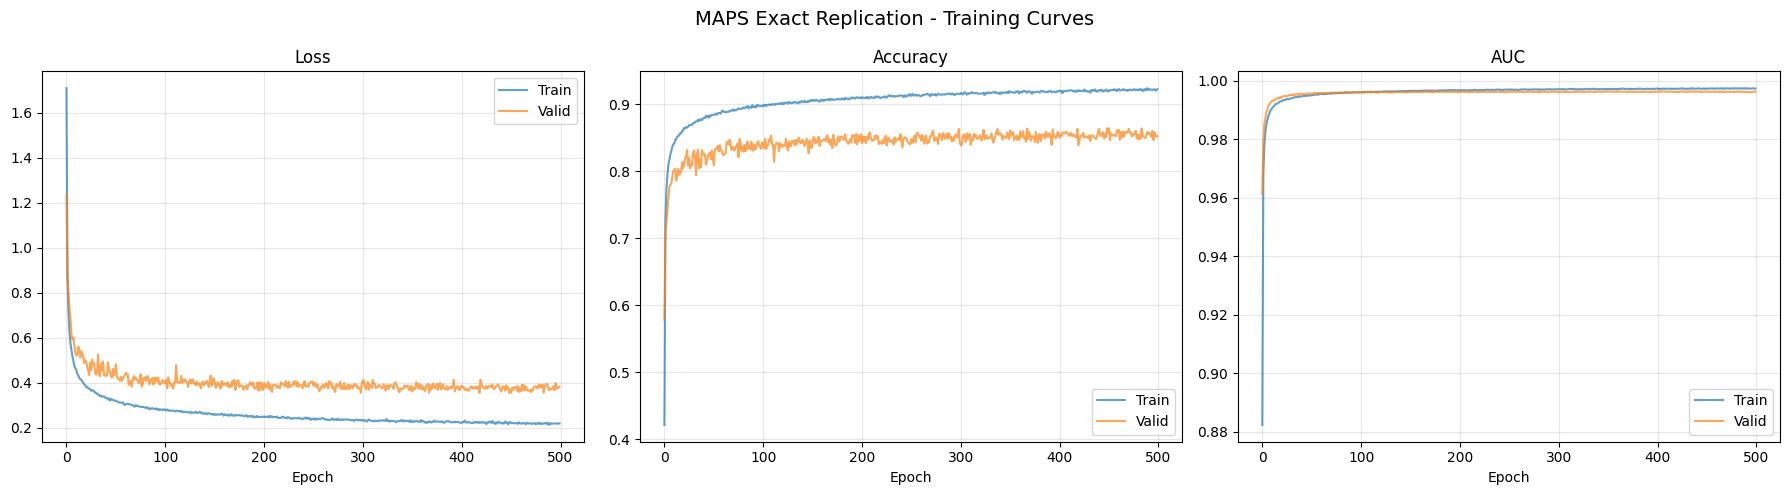

In [14]:
# Training curves
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train', alpha=0.7)
axes[0].plot(history['valid_loss'], label='Valid', alpha=0.7)
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train', alpha=0.7)
axes[1].plot(history['valid_acc'], label='Valid', alpha=0.7)
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['train_auc'], label='Train', alpha=0.7)
axes[2].plot(history['valid_auc'], label='Valid', alpha=0.7)
axes[2].set_title('AUC')
axes[2].set_xlabel('Epoch')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('MAPS Exact Replication - Training Curves', fontsize=14)
plt.tight_layout()
plt.show()

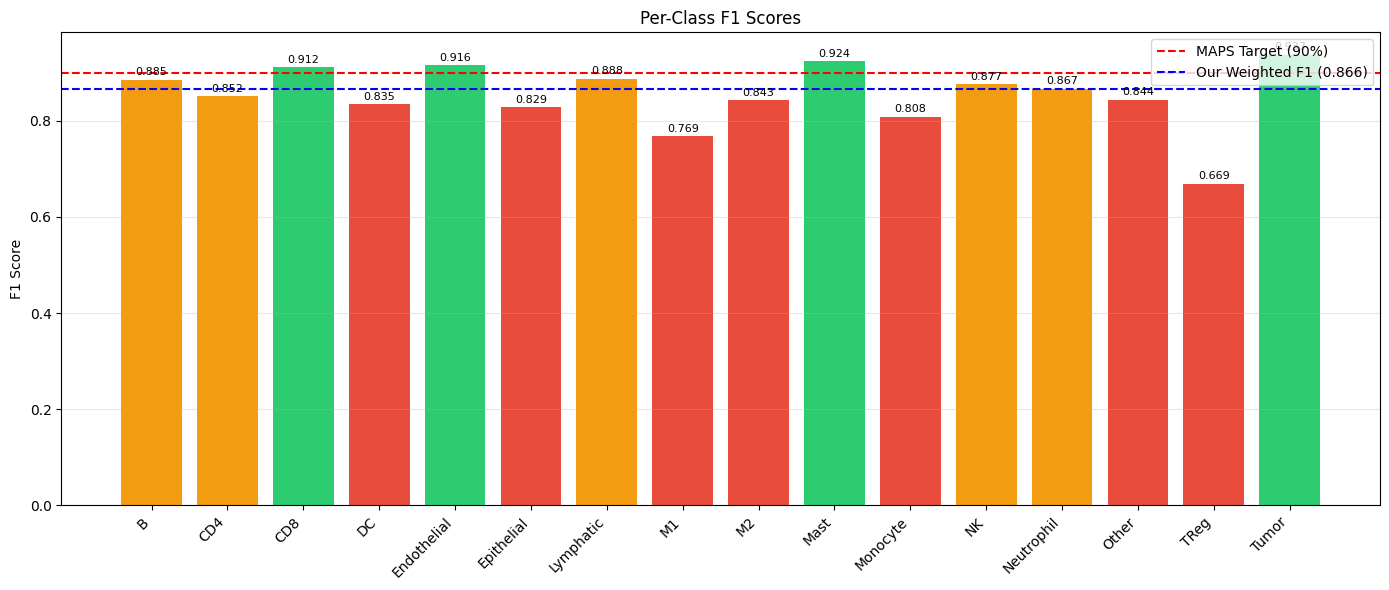


Weakest classes (targets for improvement):
  TReg           : F1 = 0.6694
  M1             : F1 = 0.7687
  Monocyte       : F1 = 0.8083
  Epithelial     : F1 = 0.8285
  DC             : F1 = 0.8352


In [15]:
# Per-class F1 bar chart
per_class_f1 = f1_score(gt_labels, pred_labels, average=None)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#e74c3c' if f < 0.85 else '#f39c12' if f < 0.90 else '#2ecc71' for f in per_class_f1]
bars = ax.bar(range(NUM_CLASSES), per_class_f1, color=colors)
ax.axhline(y=0.90, color='red', linestyle='--', label='MAPS Target (90%)')
ax.axhline(y=weighted_f1, color='blue', linestyle='--', label=f'Our Weighted F1 ({weighted_f1:.3f})')

ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Scores')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for i, (bar, f) in enumerate(zip(bars, per_class_f1)):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{f:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Identify weakest classes
sorted_classes = sorted(zip(CLASS_NAMES, per_class_f1), key=lambda x: x[1])
print("\nWeakest classes (targets for improvement):")
for name, f in sorted_classes[:5]:
    print(f"  {name:15s}: F1 = {f:.4f}")

In [16]:
# ====================================================================
# SUMMARY
# ====================================================================
print("\n" + "=" * 60)
print("EXPERIMENT 10: EXACT MAPS REPLICATION - SUMMARY")
print("=" * 60)
print(f"\n  Architecture: 4-layer MLP (50→512→512→512→512→16)")
print(f"  Precision:    float64")
print(f"  Normalization: z-score + /255.0")
print(f"  Features:     50 (49 markers + cellSize)")
print(f"  Seed:          {SEED}")
print(f"  Epochs run:   {len(history['train_loss'])}")
print(f"\n  --- Results ---")
print(f"  Weighted F1:  {weighted_f1:.4f}")
print(f"  Macro F1:     {macro_f1:.4f}")
print(f"  Accuracy:     {accuracy:.4f}")
print(f"\n  vs MAPS target (0.90): {'✅ MATCHED' if weighted_f1 >= 0.90 else f'Gap = {(0.90-weighted_f1)*100:.1f}pp'}")
print(f"  vs our previous best (0.882): {'✅ IMPROVED' if weighted_f1 > 0.882 else 'No improvement'}")


EXPERIMENT 10: EXACT MAPS REPLICATION - SUMMARY

  Architecture: 4-layer MLP (50→512→512→512→512→16)
  Precision:    float64
  Normalization: z-score + /255.0
  Features:     50 (49 markers + cellSize)
  Seed:          7325111
  Epochs run:   500

  --- Results ---
  Weighted F1:  0.8655
  Macro F1:     0.8534
  Accuracy:     0.8642

  vs MAPS target (0.90): Gap = 3.4pp
  vs our previous best (0.882): No improvement


---
# Part 2: 5-Fold Cross-Validation Ensemble (MAPS Method)

## Goal: Replicate MAPS's ~90% F1 Score

MAPS reports ~90% F1 using **micro-average F1** across **5-fold StratifiedKFold CV** test sets.

**Exact MAPS procedure:**
1. Full dataset → `StratifiedKFold(n_splits=5, seed=7325111)` → 5 outer folds (80% train, 20% test)
2. Each fold's train set → another `StratifiedKFold(n_splits=5, seed=7325111)`, take **first split only** → train/valid
3. Train model on train, early-stop on valid, predict on test
4. Pool ALL test predictions across 5 folds → compute F1

In [18]:
# ====================================================================
# LOAD FULL DATASET (combine pre-split train + valid)
# ====================================================================
from sklearn.model_selection import StratifiedKFold

# Load the pre-processed train/valid CSVs and combine them
# These already have Seg Artifact removed and Cytotoxic CD8 merged
DATA_DIR = os.path.join('..', 'data', 'cell_phenotyping')
df_train_full = pd.read_csv(os.path.join(DATA_DIR, '/kaggle/input/datasets/amshahriarrashidmahe/cell-phenotying/train.csv'))
df_valid_full = pd.read_csv(os.path.join(DATA_DIR, '/kaggle/input/datasets/amshahriarrashidmahe/cell-phenotying/valid.csv'))
df_all = pd.concat([df_train_full, df_valid_full], ignore_index=True)

print(f"Full dataset: {df_all.shape[0]:,} cells × {df_all.shape[1]} columns")
print(f"Features: {FEATURE_COLS[:3]}...{FEATURE_COLS[-3:]} ({len(FEATURE_COLS)} total)")

X_all = df_all[FEATURE_COLS].values.astype(np.float64)  # MAPS uses float64
y_all = df_all['cell_label'].values.astype(np.int64)

print(f"\nClass distribution:")
for idx, name in enumerate(CLASS_NAMES):
    count = (y_all == idx).sum()
    print(f"  {idx:2d}. {name:15s}: {count:6d} ({100*count/len(y_all):.1f}%)")

Full dataset: 143,730 cells × 51 columns
Features: ['BCL.2', 'CCR6', 'CD11b']...['a.SMA', 'b.Catenin', 'cellSize'] (50 total)

Class distribution:
   0. B              :  16196 (11.3%)
   1. CD4            :  37480 (26.1%)
   2. CD8            :  17568 (12.2%)
   3. DC             :   9637 (6.7%)
   4. Endothelial    :   8705 (6.1%)
   5. Epithelial     :   2251 (1.6%)
   6. Lymphatic      :   3768 (2.6%)
   7. M1             :   3101 (2.2%)
   8. M2             :   7286 (5.1%)
   9. Mast           :   3324 (2.3%)
  10. Monocyte       :   6913 (4.8%)
  11. NK             :   7339 (5.1%)
  12. Neutrophil     :   3442 (2.4%)
  13. Other          :   5108 (3.6%)
  14. TReg           :   3352 (2.3%)
  15. Tumor          :   8260 (5.7%)


## 6. Create 5-Fold Splits (Exact MAPS Procedure)

In [19]:
# ====================================================================
# CREATE EXACT MAPS 5-FOLD SPLITS
# ====================================================================
# Outer split: full dataset → 5 folds (80% train_pool, 20% test)
# Inner split: each fold's train_pool → train/valid (first split only)

OUTER_SEED = 7325111
INNER_SEED = 7325111

outer_skf = StratifiedKFold(n_splits=5, random_state=OUTER_SEED, shuffle=True)

folds = []
for fold_idx, (train_pool_idx, test_idx) in enumerate(outer_skf.split(X_all, y_all)):
    # Inner split: take first split of another StratifiedKFold on the train pool
    inner_skf = StratifiedKFold(n_splits=5, random_state=INNER_SEED, shuffle=True)
    for train_idx_inner, valid_idx_inner in inner_skf.split(X_all[train_pool_idx], y_all[train_pool_idx]):
        # Map inner indices back to full dataset indices
        train_idx = train_pool_idx[train_idx_inner]
        valid_idx = train_pool_idx[valid_idx_inner]
        break  # MAPS only takes the FIRST inner split
    
    fold_info = {
        'fold': fold_idx,
        'train_idx': train_idx,
        'valid_idx': valid_idx,
        'test_idx': test_idx,
    }
    folds.append(fold_info)
    
    print(f"Fold {fold_idx}: train={len(train_idx):,} | valid={len(valid_idx):,} | test={len(test_idx):,}")

print(f"\nTotal test cells across all folds: {sum(len(f['test_idx']) for f in folds):,}")
print(f"(Should equal full dataset: {len(y_all):,})")

Fold 0: train=91,987 | valid=22,997 | test=28,746
Fold 1: train=91,987 | valid=22,997 | test=28,746
Fold 2: train=91,987 | valid=22,997 | test=28,746
Fold 3: train=91,987 | valid=22,997 | test=28,746
Fold 4: train=91,987 | valid=22,997 | test=28,746

Total test cells across all folds: 143,730
(Should equal full dataset: 143,730)


## 7. Train 5 Models (One Per Fold)

Each model is trained with the **exact same hyperparameters** as MAPS:
- Architecture: 4-layer MLP (50→512→512→512→512→16)
- Precision: float64
- Dropout: 0.25
- LR: 0.001, Patience: 150, Min epochs: 350, Max epochs: 500
- Normalization: z-score + /255.0
- WeightedRandomSampler for class balancing

In [20]:
# ====================================================================
# 5-FOLD TRAINING LOOP
# ====================================================================
# Reuses: MLP, CellDataset, make_weighted_sampler, train_epoch, valid_epoch, set_seed
# from the single-model section above

all_test_labels = []   # pooled ground truth labels
all_test_preds = []    # pooled predicted labels  
all_test_probs = []    # pooled predicted probabilities
fold_results = []      # per-fold metrics
fold_models = []       # saved model states

for fold_info in folds:
    fold_idx = fold_info['fold']
    train_idx = fold_info['train_idx']
    valid_idx = fold_info['valid_idx']
    test_idx = fold_info['test_idx']
    
    print(f"\n{'='*80}")
    print(f"  FOLD {fold_idx} — Train: {len(train_idx):,} | Valid: {len(valid_idx):,} | Test: {len(test_idx):,}")
    print(f"{'='*80}")
    
    # Extract fold data
    X_fold_train = X_all[train_idx]
    y_fold_train = y_all[train_idx]
    X_fold_valid = X_all[valid_idx]
    y_fold_valid = y_all[valid_idx]
    X_fold_test = X_all[test_idx]
    y_fold_test = y_all[test_idx]
    
    # Create datasets (exact MAPS normalization: z-score on train, applied to valid/test)
    train_ds = CellDataset(X_fold_train, y_fold_train, is_train=True)
    valid_ds = CellDataset(X_fold_valid, y_fold_valid, is_train=False,
                           mean=train_ds.mean, std=train_ds.std)
    test_ds = CellDataset(X_fold_test, y_fold_test, is_train=False,
                          mean=train_ds.mean, std=train_ds.std)
    
    # Create data loaders
    train_sampler = make_weighted_sampler(y_fold_train)
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=train_sampler,
                          drop_last=True, num_workers=NUM_WORKERS)
    valid_dl = DataLoader(valid_ds, batch_size=BATCH_SIZE,
                          sampler=SequentialSampler(valid_ds),
                          drop_last=False, num_workers=NUM_WORKERS)
    test_dl = DataLoader(test_ds, batch_size=BATCH_SIZE,
                         sampler=SequentialSampler(test_ds),
                         drop_last=False, num_workers=NUM_WORKERS)
    
    # Initialize model (fresh for each fold)
    set_seed(SEED)
    fold_model = MLP(input_dim=NUM_FEATURES, hidden_dim=HIDDEN_DIM,
                     num_classes=NUM_CLASSES, dropout=DROPOUT)
    fold_model.to(DEVICE, dtype=torch.float64)
    
    fold_optimizer = optim.Adam(fold_model.parameters(), lr=LR)
    fold_loss_fn = nn.CrossEntropyLoss()
    
    # Training loop with early stopping
    best_loss = float('inf')
    patience_ctr = 0
    best_state = None
    
    for epoch in range(MAX_EPOCHS):
        # Train
        fold_model.train()
        epoch_loss = 0
        for features, labels in train_dl:
            features = features.to(DEVICE)
            labels = labels.to(DEVICE)
            logits, probs = fold_model(features)
            fold_optimizer.zero_grad()
            loss = fold_loss_fn(logits, labels)
            loss.backward()
            fold_optimizer.step()
            epoch_loss += loss.item()
        
        # Validate
        fold_model.eval()
        val_loss = 0
        with torch.no_grad():
            for features, labels in valid_dl:
                features = features.to(DEVICE)
                labels = labels.to(DEVICE)
                logits, probs = fold_model(features)
                loss = fold_loss_fn(logits, labels)
                val_loss += loss.item()
        
        avg_val_loss = val_loss / len(valid_dl)
        
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            best_state = {k: v.clone() for k, v in fold_model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
        
        if epoch % 50 == 0:
            print(f"  Epoch {epoch:3d} | Val Loss: {avg_val_loss:.4f} | Best: {best_loss:.4f} | Patience: {patience_ctr}/{PATIENCE}")
        
        if patience_ctr > PATIENCE and epoch >= MIN_EPOCHS:
            print(f"  Early stopping at epoch {epoch}")
            break
    
    print(f"  Training complete — {epoch+1} epochs, best val loss: {best_loss:.4f}")
    
    # Load best model and predict on TEST set
    fold_model.load_state_dict(best_state)
    fold_model.eval()
    
    test_labels_fold = []
    test_preds_fold = []
    test_probs_fold = []
    
    with torch.no_grad():
        for features, labels in test_dl:
            features = features.to(DEVICE)
            logits, probs = fold_model(features)
            preds = torch.argmax(probs, dim=1)
            test_labels_fold.extend(labels.cpu().numpy().tolist())
            test_preds_fold.extend(preds.cpu().numpy().tolist())
            test_probs_fold.append(probs.cpu().numpy())
    
    test_probs_fold = np.concatenate(test_probs_fold, axis=0)
    
    # Per-fold metrics
    fold_wf1 = f1_score(test_labels_fold, test_preds_fold, average='weighted')
    fold_mf1 = f1_score(test_labels_fold, test_preds_fold, average='micro')
    fold_macro = f1_score(test_labels_fold, test_preds_fold, average='macro')
    fold_acc = accuracy_score(test_labels_fold, test_preds_fold)
    
    fold_results.append({
        'fold': fold_idx,
        'weighted_f1': fold_wf1,
        'micro_f1': fold_mf1,
        'macro_f1': fold_macro,
        'accuracy': fold_acc,
        'epochs': epoch + 1
    })
    
    print(f"  Fold {fold_idx} TEST results: Weighted F1={fold_wf1:.4f} | Micro F1={fold_mf1:.4f} | Acc={fold_acc:.4f}")
    
    # Pool test predictions
    all_test_labels.extend(test_labels_fold)
    all_test_preds.extend(test_preds_fold)
    all_test_probs.append(test_probs_fold)
    
    # Save model state
    fold_models.append(best_state)

all_test_probs = np.concatenate(all_test_probs, axis=0)
print(f"\n{'='*80}")
print(f"All 5 folds trained! Pooled test predictions: {len(all_test_labels):,} cells")
print(f"{'='*80}")


  FOLD 0 — Train: 91,987 | Valid: 22,997 | Test: 28,746
  Epoch   0 | Val Loss: 1.2338 | Best: 1.2338 | Patience: 0/150
  Epoch  50 | Val Loss: 0.4561 | Best: 0.4146 | Patience: 4/150
  Epoch 100 | Val Loss: 0.4251 | Best: 0.4013 | Patience: 9/150
  Epoch 150 | Val Loss: 0.3983 | Best: 0.3749 | Patience: 6/150
  Epoch 200 | Val Loss: 0.4074 | Best: 0.3749 | Patience: 56/150
  Epoch 250 | Val Loss: 0.3993 | Best: 0.3749 | Patience: 106/150
  Epoch 300 | Val Loss: 0.3982 | Best: 0.3749 | Patience: 156/150
  Epoch 350 | Val Loss: 0.4115 | Best: 0.3724 | Patience: 25/150
  Epoch 400 | Val Loss: 0.3766 | Best: 0.3713 | Patience: 44/150
  Epoch 450 | Val Loss: 0.3848 | Best: 0.3713 | Patience: 94/150
  Training complete — 500 epochs, best val loss: 0.3713
  Fold 0 TEST results: Weighted F1=0.8648 | Micro F1=0.8635 | Acc=0.8635

  FOLD 1 — Train: 91,987 | Valid: 22,997 | Test: 28,746
  Epoch   0 | Val Loss: 1.6748 | Best: 1.6748 | Patience: 0/150
  Epoch  50 | Val Loss: 0.4248 | Best: 0.4157

## 8. 5-Fold Ensemble Results

In [21]:
# ====================================================================
# POOLED 5-FOLD RESULTS (This is how MAPS computes their ~90% F1)
# ====================================================================

pooled_weighted_f1 = f1_score(all_test_labels, all_test_preds, average='weighted')
pooled_micro_f1 = f1_score(all_test_labels, all_test_preds, average='micro')
pooled_macro_f1 = f1_score(all_test_labels, all_test_preds, average='macro')
pooled_accuracy = accuracy_score(all_test_labels, all_test_preds)

print("=" * 70)
print("   5-FOLD CROSS-VALIDATION ENSEMBLE RESULTS (MAPS METHOD)")
print("=" * 70)
print(f"\n   Pooled Metrics (all {len(all_test_labels):,} test cells across 5 folds):")
print(f"   ─────────────────────────────────────────────────────")
print(f"   Micro F1 (MAPS metric):     {pooled_micro_f1:.4f}  (MAPS target: ~0.90)")
print(f"   Weighted F1:                 {pooled_weighted_f1:.4f}")
print(f"   Macro F1:                    {pooled_macro_f1:.4f}")
print(f"   Accuracy:                    {pooled_accuracy:.4f}")
print()

# Per-fold breakdown
print("   Per-Fold Breakdown:")
print("   ─────────────────────────────────────────────────────")
print(f"   {'Fold':>6} │ {'Weighted F1':>12} │ {'Micro F1':>10} │ {'Macro F1':>10} │ {'Accuracy':>10} │ {'Epochs':>6}")
print(f"   {'─'*6}─┼─{'─'*12}─┼─{'─'*10}─┼─{'─'*10}─┼─{'─'*10}─┼─{'─'*6}")
for r in fold_results:
    print(f"   {r['fold']:>6} │ {r['weighted_f1']:>12.4f} │ {r['micro_f1']:>10.4f} │ {r['macro_f1']:>10.4f} │ {r['accuracy']:>10.4f} │ {r['epochs']:>6}")

wf1_scores = [r['weighted_f1'] for r in fold_results]
mf1_scores = [r['micro_f1'] for r in fold_results]
print(f"\n   Mean Weighted F1: {np.mean(wf1_scores):.4f} ± {np.std(wf1_scores):.4f}")
print(f"   Mean Micro F1:   {np.mean(mf1_scores):.4f} ± {np.std(mf1_scores):.4f}")

print("\n" + "=" * 70)
if pooled_micro_f1 >= 0.90:
    print("   🎉 SUCCESS! Matched or exceeded MAPS ~90% micro F1!")
elif pooled_micro_f1 >= 0.88:
    print(f"   📈 Very close! Gap of {(0.90 - pooled_micro_f1)*100:.1f}pp from MAPS ~90%.")
else:
    print(f"   📊 Gap of {(0.90 - pooled_micro_f1)*100:.1f}pp from MAPS ~90% target.")
print("=" * 70)

   5-FOLD CROSS-VALIDATION ENSEMBLE RESULTS (MAPS METHOD)

   Pooled Metrics (all 143,730 test cells across 5 folds):
   ─────────────────────────────────────────────────────
   Micro F1 (MAPS metric):     0.8613  (MAPS target: ~0.90)
   Weighted F1:                 0.8627
   Macro F1:                    0.8503
   Accuracy:                    0.8613

   Per-Fold Breakdown:
   ─────────────────────────────────────────────────────
     Fold │  Weighted F1 │   Micro F1 │   Macro F1 │   Accuracy │ Epochs
   ───────┼──────────────┼────────────┼────────────┼────────────┼───────
        0 │       0.8648 │     0.8635 │     0.8536 │     0.8635 │    500
        1 │       0.8604 │     0.8589 │     0.8473 │     0.8589 │    365
        2 │       0.8651 │     0.8629 │     0.8504 │     0.8629 │    412
        3 │       0.8636 │     0.8625 │     0.8533 │     0.8625 │    500
        4 │       0.8600 │     0.8588 │     0.8476 │     0.8588 │    390

   Mean Weighted F1: 0.8627 ± 0.0022
   Mean Micro F1: 

In [22]:
# ====================================================================
# PER-CLASS CLASSIFICATION REPORT (Pooled)
# ====================================================================
print("Per-Class Classification Report (Pooled across 5 folds):")
print("=" * 70)
report_5fold = classification_report(all_test_labels, all_test_preds,
                                      target_names=CLASS_NAMES, digits=4)
print(report_5fold)

Per-Class Classification Report (Pooled across 5 folds):
              precision    recall  f1-score   support

           B     0.8848    0.8648    0.8747     16196
         CD4     0.9388    0.7761    0.8497     37480
         CD8     0.9205    0.9047    0.9125     17568
          DC     0.8151    0.8314    0.8232      9637
 Endothelial     0.9086    0.9300    0.9192      8705
  Epithelial     0.6954    0.9556    0.8050      2251
   Lymphatic     0.8123    0.9546    0.8777      3768
          M1     0.6701    0.8910    0.7650      3101
          M2     0.8214    0.8533    0.8370      7286
        Mast     0.8954    0.9732    0.9327      3324
    Monocyte     0.7916    0.8345    0.8125      6913
          NK     0.8691    0.8922    0.8805      7339
  Neutrophil     0.8285    0.9152    0.8697      3442
       Other     0.7748    0.9011    0.8332      5108
        TReg     0.5612    0.8505    0.6762      3352
       Tumor     0.9264    0.9469    0.9365      8260

    accuracy           

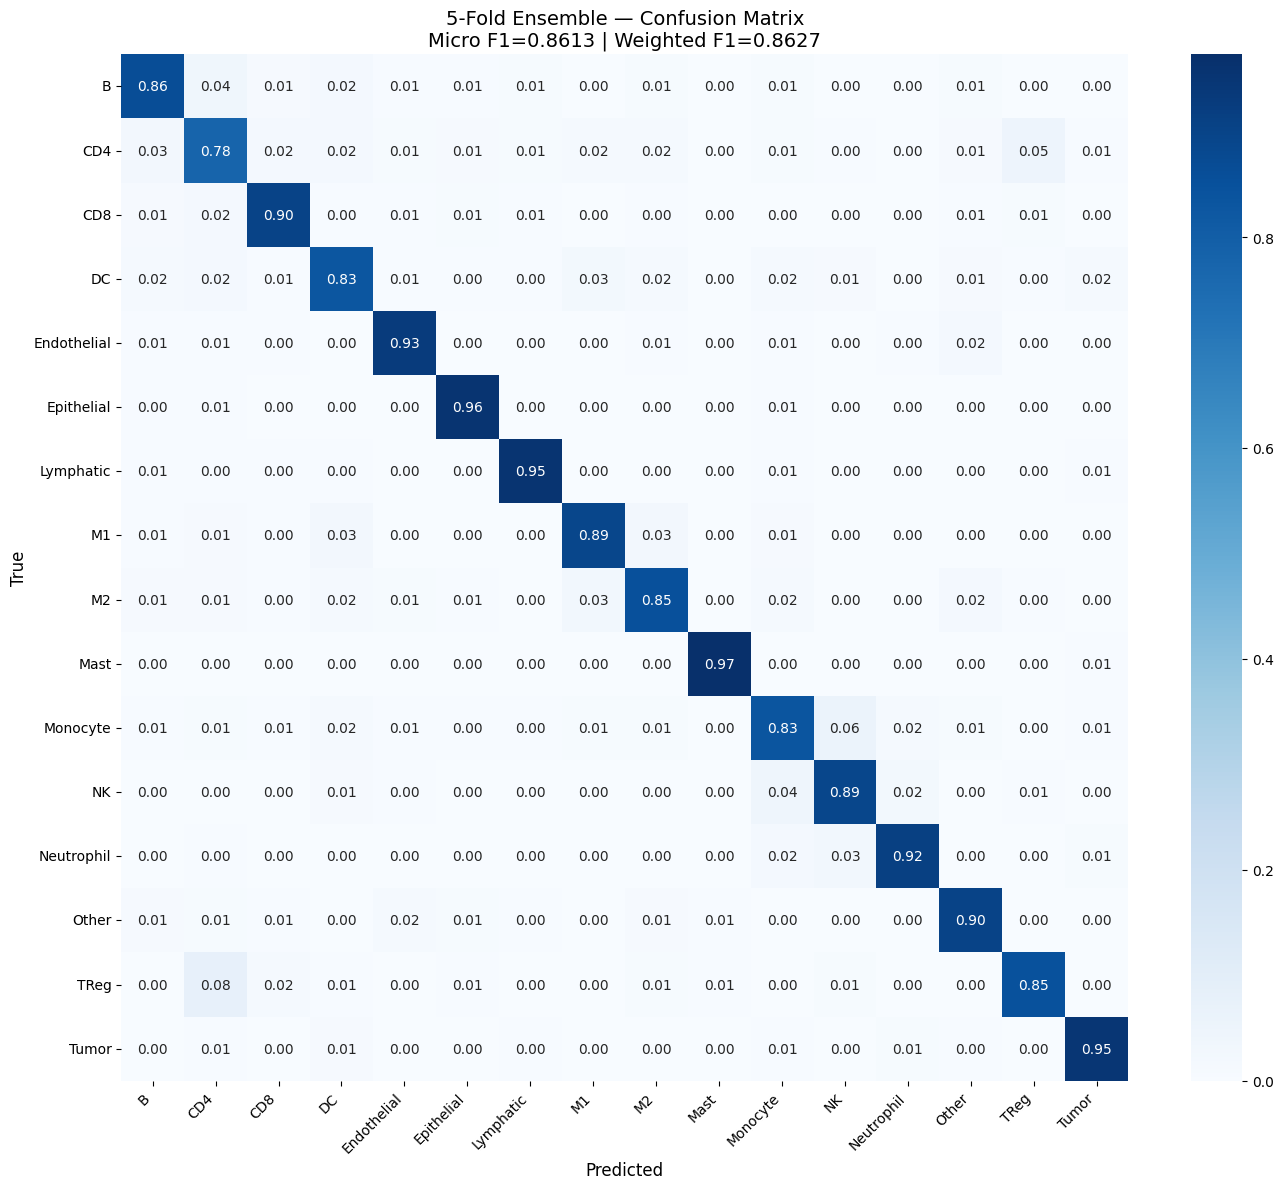

In [23]:
# ====================================================================
# CONFUSION MATRIX (Pooled 5-Fold)
# ====================================================================
fig, ax = plt.subplots(figsize=(14, 12))
cm_5fold = confusion_matrix(all_test_labels, all_test_preds)
cm_5fold_norm = cm_5fold.astype('float') / cm_5fold.sum(axis=1, keepdims=True)

sns.heatmap(cm_5fold_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title(f'5-Fold Ensemble — Confusion Matrix\n'
             f'Micro F1={pooled_micro_f1:.4f} | Weighted F1={pooled_weighted_f1:.4f}',
             fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

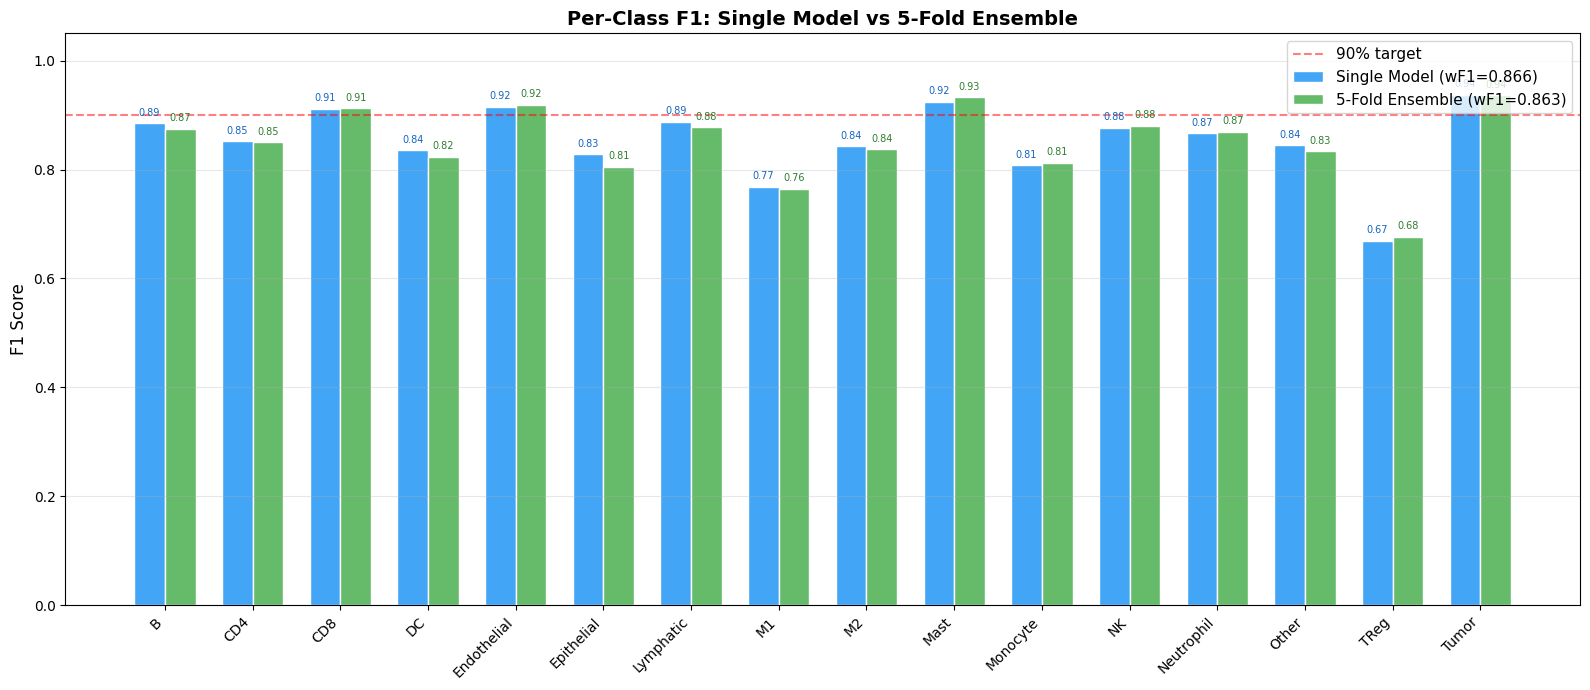


Per-class improvement (5-Fold vs Single):
  B              : 0.8854 → 0.8747  (↓ 1.1pp)
  CD4            : 0.8517 → 0.8497  (↓ 0.2pp)
  CD8            : 0.9115 → 0.9125  (↑ 0.1pp)
  DC             : 0.8352 → 0.8232  (↓ 1.2pp)
  Endothelial    : 0.9156 → 0.9192  (↑ 0.4pp)
  Epithelial     : 0.8285 → 0.8050  (↓ 2.4pp)
  Lymphatic      : 0.8878 → 0.8777  (↓ 1.0pp)
  M1             : 0.7687 → 0.7650  (↓ 0.4pp)
  M2             : 0.8426 → 0.8370  (↓ 0.6pp)
  Mast           : 0.9243 → 0.9327  (↑ 0.8pp)
  Monocyte       : 0.8083 → 0.8125  (↑ 0.4pp)
  NK             : 0.8767 → 0.8805  (↑ 0.4pp)
  Neutrophil     : 0.8671 → 0.8697  (↑ 0.3pp)
  Other          : 0.8442 → 0.8332  (↓ 1.1pp)
  TReg           : 0.6694 → 0.6762  (↑ 0.7pp)
  Tumor          : 0.9374 → 0.9365  (↓ 0.1pp)


In [24]:
# ====================================================================
# PER-CLASS F1: Single Model vs 5-Fold Ensemble
# ====================================================================
per_class_f1_5fold = f1_score(all_test_labels, all_test_preds, average=None)

fig, ax = plt.subplots(figsize=(16, 7))

x = np.arange(NUM_CLASSES)
width = 0.35

# Single model per-class F1 (from Part 1)
bars1 = ax.bar(x - width/2, per_class_f1, width, label=f'Single Model (wF1={weighted_f1:.3f})',
               color='#42A5F5', edgecolor='white')
# 5-fold per-class F1
bars2 = ax.bar(x + width/2, per_class_f1_5fold, width, label=f'5-Fold Ensemble (wF1={pooled_weighted_f1:.3f})',
               color='#66BB6A', edgecolor='white')

ax.axhline(y=0.90, color='red', linestyle='--', alpha=0.5, label='90% target')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=10)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Per-Class F1: Single Model vs 5-Fold Ensemble', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar in bars1:
    if bar.get_height() > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7, color='#1565C0')
for bar in bars2:
    if bar.get_height() > 0.01:
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7, color='#2E7D32')

plt.tight_layout()
plt.show()

# Print improvement per class
print("\nPer-class improvement (5-Fold vs Single):")
for i, name in enumerate(CLASS_NAMES):
    diff = per_class_f1_5fold[i] - per_class_f1[i]
    arrow = "↑" if diff > 0 else "↓" if diff < 0 else "="
    print(f"  {name:15s}: {per_class_f1[i]:.4f} → {per_class_f1_5fold[i]:.4f}  ({arrow} {abs(diff)*100:.1f}pp)")

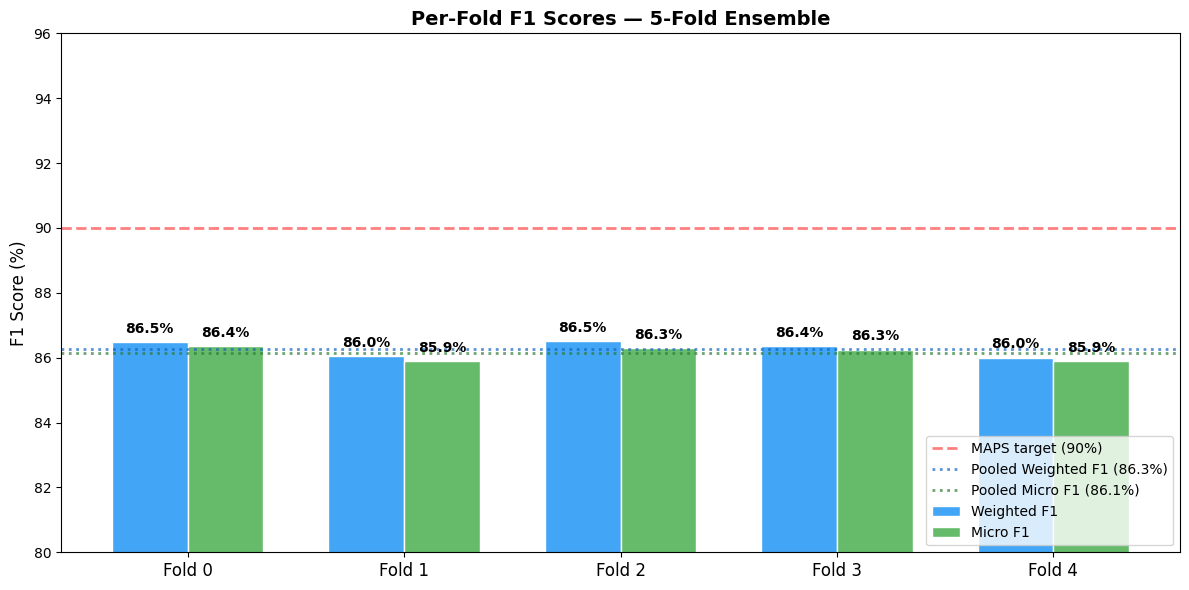

In [25]:
# ====================================================================
# PER-FOLD F1 SCORES BAR CHART
# ====================================================================
fig, ax = plt.subplots(figsize=(12, 6))

fold_nums = [r['fold'] for r in fold_results]
wf1_vals = [r['weighted_f1'] for r in fold_results]
mf1_vals = [r['micro_f1'] for r in fold_results]

x = np.arange(len(fold_nums))
width = 0.35

bars1 = ax.bar(x - width/2, [v*100 for v in wf1_vals], width, label='Weighted F1', color='#42A5F5', edgecolor='white')
bars2 = ax.bar(x + width/2, [v*100 for v in mf1_vals], width, label='Micro F1', color='#66BB6A', edgecolor='white')

ax.axhline(y=90, color='red', linestyle='--', alpha=0.5, linewidth=2, label='MAPS target (90%)')
ax.axhline(y=pooled_weighted_f1*100, color='#1565C0', linestyle=':', alpha=0.7, linewidth=2,
           label=f'Pooled Weighted F1 ({pooled_weighted_f1*100:.1f}%)')
ax.axhline(y=pooled_micro_f1*100, color='#2E7D32', linestyle=':', alpha=0.7, linewidth=2,
           label=f'Pooled Micro F1 ({pooled_micro_f1*100:.1f}%)')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i}' for i in fold_nums], fontsize=12)
ax.set_ylabel('F1 Score (%)', fontsize=12)
ax.set_title('Per-Fold F1 Scores — 5-Fold Ensemble', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(80, 96)
plt.tight_layout()
plt.show()

In [30]:
# ====================================================================
# FINAL SUMMARY: EXPERIMENT 10
# ====================================================================
print("\n" + "=" * 70)
print("  EXPERIMENT 10: EXACT MAPS REPLICATION — FINAL SUMMARY")
print("=" * 70)

print(f"\n  Architecture: 4-layer MLP (50→512→512→512→512→16)")
print(f"  Precision:    float64")
print(f"  Normalization: z-score + /255.0")
print(f"  Dropout:      {DROPOUT}")
print(f"  Seed:         {SEED}")

print(f"\n  ┌─────────────────────────────────────────────────────┐")
print(f"  │  Part 1: Single Model (Pre-split train/valid)       │")
print(f"  │  Weighted F1:  {weighted_f1:.4f}                              │")
print(f"  │  Accuracy:     {accuracy:.4f}                              │")
print(f"  ├─────────────────────────────────────────────────────┤")
print(f"  │  Part 2: 5-Fold CV Ensemble (MAPS method)           │")
print(f"  │  Micro F1:     {pooled_micro_f1:.4f}  (MAPS target: ~0.90)    │")
print(f"  │  Weighted F1:  {pooled_weighted_f1:.4f}                              │")
print(f"  │  Macro F1:     {pooled_macro_f1:.4f}                              │")
print(f"  │  Accuracy:     {pooled_accuracy:.4f}                              │")
print(f"  ├─────────────────────────────────────────────────────┤")
print(f"  │  MAPS Reported:  ~90% micro F1 (5-fold CV)          │")
print(f"  │  MAPS Ensemble:  89.7% weighted F1                  │")
print(f"  └─────────────────────────────────────────────────────┘")

gap = (0.90 - pooled_micro_f1) * 100
if pooled_micro_f1 >= 0.90:
    print(f"\n  ✅ MATCHED MAPS! Micro F1 = {pooled_micro_f1:.4f} ≥ 0.90")
elif pooled_micro_f1 >= 0.89:
    print(f"\n  📈 Very close! Gap = {gap:.1f}pp from MAPS ~90% micro F1")
else:
    print(f"\n  📊 Gap = {gap:.1f}pp from MAPS ~90% micro F1")

print("=" * 70)


  EXPERIMENT 10: EXACT MAPS REPLICATION — FINAL SUMMARY

  Architecture: 4-layer MLP (50→512→512→512→512→16)
  Precision:    float64
  Normalization: z-score + /255.0
  Dropout:      0.25
  Seed:         7325111

  ┌─────────────────────────────────────────────────────┐
  │  Part 1: Single Model (Pre-split train/valid)       │
  │  Weighted F1:  0.8655                              │
  │  Accuracy:     0.8642                              │
  ├─────────────────────────────────────────────────────┤
  │  Part 2: 5-Fold CV Ensemble (MAPS method)           │
  │  Micro F1:     0.8613  (MAPS target: ~0.90)    │
  │  Weighted F1:  0.8627                              │
  │  Macro F1:     0.8503                              │
  │  Accuracy:     0.8613                              │
  ├─────────────────────────────────────────────────────┤
  │  MAPS Reported:  ~90% micro F1 (5-fold CV)          │
  │  MAPS Ensemble:  89.7% weighted F1                  │
  └───────────────────────────────────────